In [ ]:


import numpy as np
import matplotlib.pyplot as plt

print("Environment ready.")

Environment ready.


In [ ]:
class HebbianModel:
    def __init__(self, input_size):
        # Initialize weights and bias to 0
        self.weights = np.zeros(input_size)
        self.bias = 0

    def train(self, x_train, y_train):
        print("--- Training Progress ---")
        for i in range(len(x_train)):
            # Hebbian Rule: Δw = x * y
            self.weights += x_train[i] * y_train[i]
            self.bias += y_train[i]
            print(f"Sample {i+1}: Input {x_train[i]} -> Weights: {self.weights}, Bias: {self.bias}")

    def predict(self, x):
        # Activation function: Signum (1 if >= 0, else -1)
        total_input = np.dot(x, self.weights) + self.bias
        return 1 if total_input >= 0 else -1

In [ ]:
# Bipolar inputs for AND gate: [x1, x2]
# (1, 1) -> 1 (True)
# Others -> -1 (False)
x_train = np.array([
    [1, 1],
    [1, -1],
    [-1, 1],
    [-1, -1]
])

y_train = np.array([1, -1, -1, -1])

print("Data prepared for AND gate logic.")

Data prepared for AND gate logic.


In [ ]:
# Initialize model for 2 inputs
model = HebbianModel(input_size=2)

# Train
model.train(x_train, y_train)

# Test the model
print("\n--- Final Predictions ---")
for x in x_train:
    prediction = model.predict(x)
    print(f"Input: {x} | Predicted Output: {prediction}")

--- Training Progress ---
Sample 1: Input [1 1] -> Weights: [1. 1.], Bias: 1
Sample 2: Input [ 1 -1] -> Weights: [0. 2.], Bias: 0
Sample 3: Input [-1  1] -> Weights: [1. 1.], Bias: -1
Sample 4: Input [-1 -1] -> Weights: [2. 2.], Bias: -2

--- Final Predictions ---
Input: [1 1] | Predicted Output: 1
Input: [ 1 -1] | Predicted Output: -1
Input: [-1  1] | Predicted Output: -1
Input: [-1 -1] | Predicted Output: -1


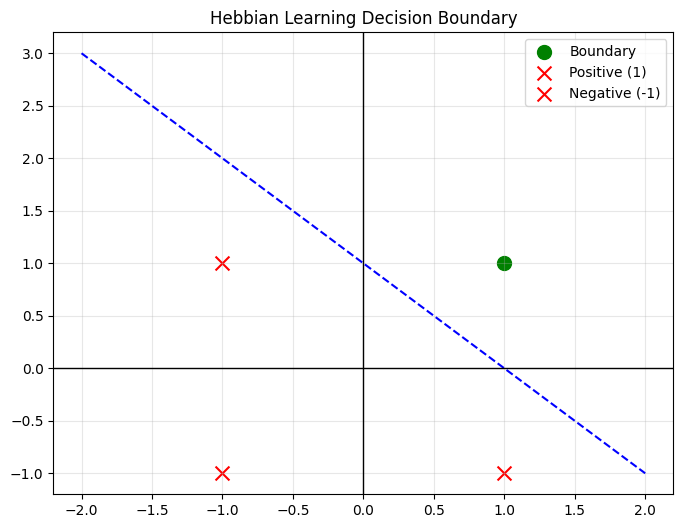

In [ ]:
def plot_hebbian(model, x_data, y_data):
    plt.figure(figsize=(8, 6))

    # Plot data points
    for i in range(len(x_data)):
        color = 'green' if y_data[i] == 1 else 'red'
        marker = 'o' if y_data[i] == 1 else 'x'
        plt.scatter(x_data[i][0], x_data[i][1], c=color, marker=marker, s=100)

    # Calculate the decision boundary line: w1*x + w2*y + b = 0
    # y = -(w1*x + b) / w2
    x_boundary = np.linspace(-2, 2, 10)
    if model.weights[1] != 0:
        y_boundary = -(model.weights[0] * x_boundary + model.bias) / model.weights[1]
        plt.plot(x_boundary, y_boundary, color='blue', linestyle='--', label='Decision Boundary')

    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    plt.title("Hebbian Learning Decision Boundary")
    plt.grid(True, alpha=0.3)
    plt.legend(["Boundary", "Positive (1)", "Negative (-1)"])
    plt.show()

plot_hebbian(model, x_train, y_train)